/content/skin-lesion-classifier/source/augment_data.py:31: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.1, shift_limit=0.1, p=0.5),
/content/skin-lesion-classifier/source/augment_data.py:36: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),


Augmentation sample saved as 'augmentation_samples.png'


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Starting Training with Combined Dataset for 30 Epochs...
Epoch [1/30] - Train Loss: 0.5815 | Val Loss: 0.4964 | Val Acc: 0.7722 | Val F1: 0.5839 | Recall: 0.8205 | Prec: 0.4533
Epoch [2/30] - Train Loss: 0.4279 | Val Loss: 0.4070 | Val Acc: 0.8052 | Val F1: 0.6243 | Recall: 0.8308 | Prec: 0.5000
Epoch [3/30] - Train Loss: 0.3829 | Val Loss: 0.4096 | Val Acc: 0.8042 | Val F1: 0.6288 | Recall: 0.8513 | Prec: 0.4985
Epoch [4/30] - Train Loss: 0.3523 | Val Loss: 0.4136 | Val Acc: 0.8102 | Val F1: 0.6402 | Recall: 0.8667 | Prec: 0.5075
Epoch [5/30] - Train Loss: 0.3201 | Val Loss: 0.4625 | Val Acc: 0.8162 | Val F1: 0.6593 | Recall: 0.9128 | Prec: 0.5159
Epoch [6/30] - Train Loss: 0.3014 | Val Loss: 0.3867 | Val Acc: 0.8212 | Val F1: 0.6538 | Recall: 0.8667 | Prec: 0.5248
Epoch [7/30] - Train Loss: 0.2683 | Val Loss: 0.3532 | Val Acc: 0.8492 | Val F1: 0.6861 | Recall: 0.8462 | Prec: 0.5769
Epoch [8/30] - Train Loss: 0.2538 | Val Loss: 0.3136 | Val Acc: 0.8751 | Val F1: 0.7228 | Recall: 0.835

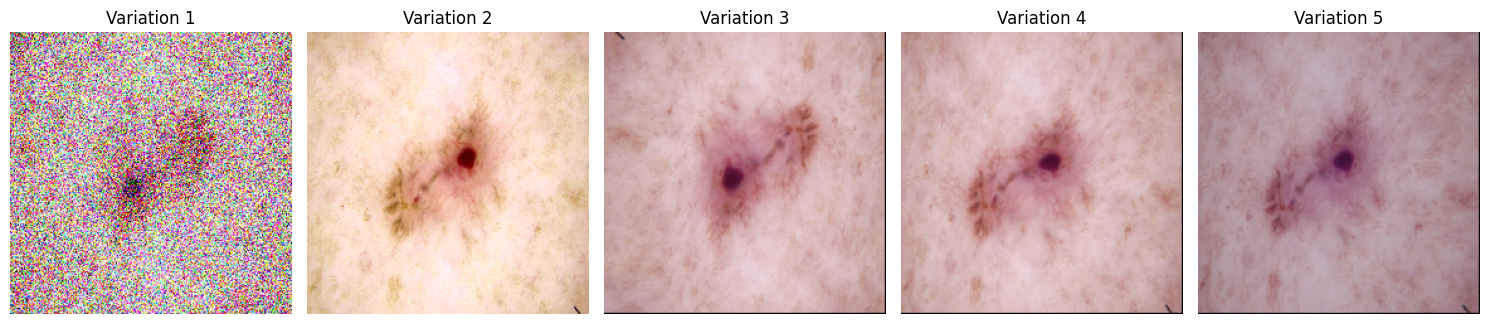

In [ ]:
# ABLATION 2: NO ISIC2019 DATASET. THIS IS PURE HAM10000 WITH ALBUMENTATIONS, WEIGHTED SAMPLING, AND ADAMW OPTIMIZER.
# Architecture: EfficientNet-B4

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import datasets
import timm
import numpy as np
import cv2
import sys
import os
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

# directory validation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), 'source')))
# assuming your augment_data.py now contains the Albumentations versions
from source.augment_data import train_transforms, val_transforms

# custom dataset class because Albumentations needs NumPy/OpenCV inputs
class AlbumentationsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.data = datasets.ImageFolder(root_dir)
        self.transform = transform

    def __getitem__(self, index):
        path, label = self.data.samples[index]
        # load image with opencv for albumentations compatibility
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label

    def __len__(self):
        return len(self.data)

# device configuration for better performance
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# folders containing combined HAM10000 and ISIC (Malignant-only) data
train_dir = '/content/skin-lesion-classifier/data/model_data/train'
val_dir = '/content/skin-lesion-classifier/data/model_data/val'

# applying the custom dataset with albumentations
train_dataset = AlbumentationsDataset(train_dir, transform=train_transforms)
val_dataset = AlbumentationsDataset(val_dir, transform=val_transforms)

# weightedrandomsampler for the imbalance (balances malignant/benign in batches)
# this looks at the combined counts of both datasets
target = np.array(train_dataset.data.targets)
class_sample_count = np.array([len(np.where(target == t)[0]) for t in np.unique(target)])
sampler_weights = 1. / class_sample_count
samples_weight = np.array([sampler_weights[t] for t in target])
sampler = WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))

# data loaders - using batch size 16 for efficientnet-b4 memory limits
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

# efficientNet-B4 - pretrained and modified for 2 classes
model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=2)
model = model.to(device)

# loss weights - using square root class weights for better precision/recall balance
loss_weights = 1. / np.sqrt(class_sample_count)
weights_tensor = torch.FloatTensor(loss_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# adamW - learning rate and weight decay optimized for stability
optimizer = optim.AdamW(model.parameters(), lr=0.0002, weight_decay=0.01)

# learning rate scheduler to reduce LR when Val Loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# training loop
num_epochs = 30
print(f"Starting Training with Combined Dataset for {num_epochs} Epochs...")

for epoch in range(num_epochs):
    # training phase
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # validation phase
    model.eval()
    all_preds = []
    all_labels = []
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # evaluation metrics to track precision/recall and accuracy baseline
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc:.4f} | Val F1: {f1:.4f} | Recall: {recall:.4f} | Prec: {precision:.4f}")

    # save the model state every 5 epochs
    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), f'efficientnet_b4_v3_epoch_{epoch+1}.pth')

# final save
torch.save(model.state_dict(), 'efficientnet_b4_v3_baseline_final.pth')
print("Training Complete. Combined models saved.")